In [1]:
from modules.strategies import Base_RSI
from backtesting_engine.backtest_engine import BacktestEngine
from modules.data import generate_historical_data
from datetime import datetime, timedelta

import cProfile
import pstats

In [2]:
strategy_configs = {
    'RSI': {
        'stream_key': 'alpaca',
        'tickers': ['AAPL','AMD','CSCO','GOOG','INTC','JNPR','META','MSFT','NFLX','NVDA','TSLA'],  # List of tickers to trade
        'period': 14,  # Historical data required per new price entry
        'overbought_th': {'entry': 55, 'exit':50},  # Overbought threshold for RSI
        'oversold_th': {'entry': 45, 'exit':50},  # Oversold threshold for RSI
        'plot':False,
    },
}

strategy_name = 'RSI'

In [3]:
tickers =  strategy_configs[strategy_name]['tickers'][0]
start_time = datetime.now() - timedelta(days=1)  
end_time = datetime.now()
historical_data = generate_historical_data(tickers, start_time, end_time)
historical_data.sort_values(by='timestamp', inplace=True)
#historical_data = historical_data.iloc[:15]
historical_data.head()

,timestamp,ticker,open,high,low,close
0,2025-03-28 01:28:26.376160,AAPL,147.48,148.43,144.73,144.89
1,2025-03-28 01:29:26.376160,AAPL,151.96,154.45,145.02,149.99
2,2025-03-28 01:30:26.376160,AAPL,152.48,156.64,152.02,155.14
3,2025-03-28 01:31:26.376160,AAPL,147.30,151.58,147.04,149.58
4,2025-03-28 01:32:26.376160,AAPL,161.05,164.44,155.82,156.76


In [4]:
%%time
#profiler = cProfile.Profile()
#profiler.enable()
strategy1 = Base_RSI(strategy_configs[strategy_name], mode='backtest')
backtest1 = BacktestEngine(strategy1, historical_data)
backtest1.run_backtest1()
#profiler.disable()

Positions initialized: {'AAPL': None, 'AMD': None, 'CSCO': None, 'GOOG': None, 'INTC': None, 'JNPR': None, 'META': None, 'MSFT': None, 'NFLX': None, 'NVDA': None, 'TSLA': None}
CPU times: total: 1.02 s
Wall time: 1.05 s


In [12]:
%%time
profiler = cProfile.Profile()
profiler.enable()
strategy2 = Base_RSI(strategy_configs[strategy_name], mode='backtest')
backtest2 = BacktestEngine(strategy2, historical_data)
backtest2.run_backtest2()
profiler.disable()

Positions initialized: {'AAPL': None, 'AMD': None, 'CSCO': None, 'GOOG': None, 'INTC': None, 'JNPR': None, 'META': None, 'MSFT': None, 'NFLX': None, 'NVDA': None, 'TSLA': None}
CPU times: total: 1.16 s
Wall time: 1.18 s


In [13]:
stats = pstats.Stats(profiler)
stats.strip_dirs().sort_stats("cumulative").print_stats(20)  # Show top 20 slowest calls

         1928858 function calls (1907152 primitive calls) in 1.175 seconds

   Ordered by: cumulative time
   List reduced from 604 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1441    0.012    0.000    1.012    0.001 frame.py:1559(itertuples)
        1    0.017    0.017    0.916    0.916 backtest_engine.py:86(run_backtest2)
1445/1443    0.003    0.000    0.748    0.001 {method 'extend' of 'list' objects}
    11528    0.010    0.000    0.745    0.000 frame.py:1630(<genexpr>)
    10087    0.033    0.000    0.731    0.000 indexing.py:1176(__getitem__)
    10087    0.021    0.000    0.604    0.000 indexing.py:1689(_getitem_tuple)
    10087    0.042    0.000    0.434    0.000 indexing.py:1032(_getitem_lowerdim)
    10087    0.024    0.000    0.327    0.000 indexing.py:1719(_getitem_axis)
    10093    0.017    0.000    0.237    0.000 frame.py:3983(_ixs)
     1441    0.074    0.000    0.210    0.000 __init__.py:355(namedtuple)
  

In [7]:
#self.historical_data[time,ticker,ohlc]
backtest2.historical_data.iloc[:,:6].equals(backtest1.historical_data.iloc[:,:6])

True

In [8]:
backtest1.balance_hist == backtest2.balance_hist

True

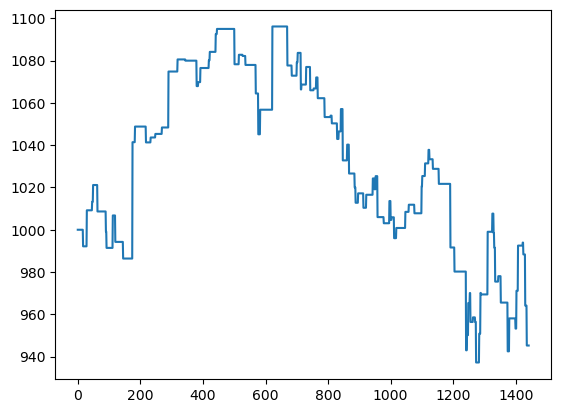

In [9]:
import matplotlib.pyplot as plt
plt.plot(backtest1.balance_hist)

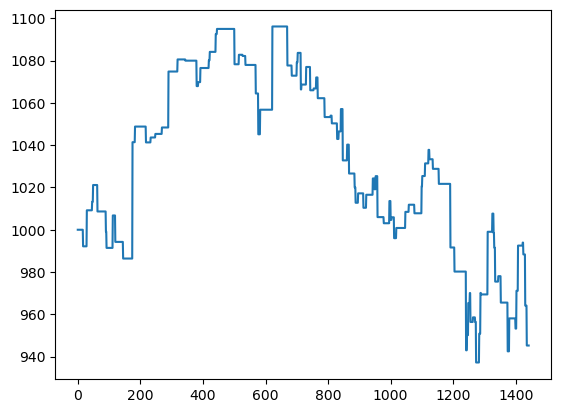

In [10]:
plt.plot(backtest2.balance_hist)

In [11]:
import numpy as np
import pandas as pd

def compare_backtests(strategy, historical_data):
    """
    Runs both versions of run_backtest and compares results.
    """
    print("Running backtest1...")
    backtest1 = BacktestEngine(strategy, historical_data.copy())
    backtest1.run_backtest1()
    
    print("Running backtest2...")
    backtest2 = BacktestEngine(strategy, historical_data.copy())
    backtest2.run_backtest2()
    
    # Convert trade history to DataFrame for comparison
    trades1 = pd.DataFrame(backtest1.trade_hist)
    trades2 = pd.DataFrame(backtest2.trade_hist)
    
    # Convert balance history to numpy arrays for direct comparison
    balance1 = np.array(backtest1.balance_hist)
    balance2 = np.array(backtest2.balance_hist)
    
    # Check if trades match
    trade_diff = trades1.compare(trades2) if not trades1.equals(trades2) else None
    
    # Check if balances match
    balance_match = np.allclose(balance1, balance2, atol=1e-6)
    
    print("--- Backtest Comparison Results ---")
    if trade_diff is None:
        print("✅ Trade histories match exactly!")
    else:
        print("❌ Trade histories differ!")
        print(trade_diff)
    
    if balance_match:
        print("✅ Balance histories match exactly!")
    else:
        print("❌ Balance histories differ!")
        print("Balance Differences:", balance1 - balance2)
    
    return trade_diff, balance1 - balance2 if not balance_match else None

#compare_backtests(strategy1, historical_data)